In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [17]:
#parameters
N = 10
wc = 1.0 * 2 * np.pi  #cavity frequency
wa = 1.0 * 2 * np.pi  #atom frequency

use_rwa = True  #employ rwa

a = tensor(destroy(N), qeye(2))
sm = tensor(qeye(N), destroy(2))

H0 = wc * a.dag() * a + wa * sm.dag() * sm
if use_rwa:
    H1 = a.dag() * sm + a * sm.dag()
else:
    H1 = (a.dag() + a) * (sm.dag() + sm)

In [18]:
#ground state psi_0 for different coupling strength g
g_val = np.linspace(0, 4, 401) * 2 * np.pi
psi_0 = []

for g in g_val:
    H = H0 + g * H1
    gnd_energy, gnd_state = H.groundstate()
    psi_0.append(gnd_state)

na = sm.dag() * sm
nc = a.dag() * a
na = expect(na, psi_0)  #atom occupation probability
nc = expect(nc, psi_0)  #cavity occupation probability

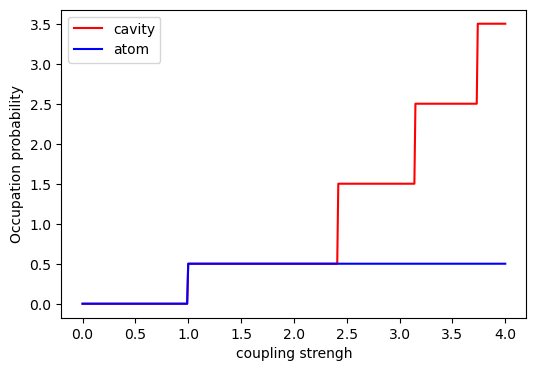

In [19]:
#occupation probability vs coupling strength
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(g_val/(2*np.pi), nc, 'r', label="cavity")
ax.plot(g_val/(2*np.pi), na, 'b', label="atom")
ax.set_ylabel("Occupation probability")
ax.set_xlabel("coupling strengh")
ax.legend(loc=0)

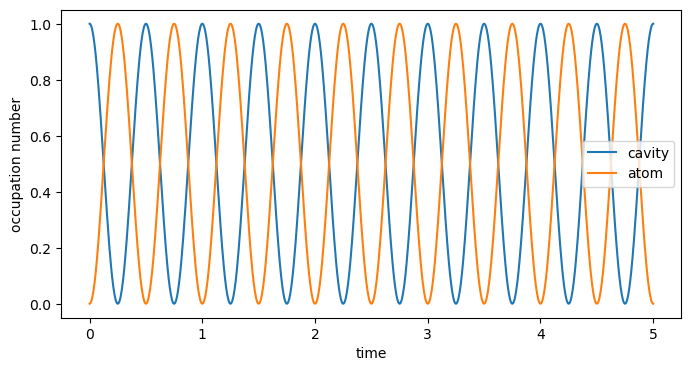

In [20]:
#dynamics of initially excited cavity, time evolution
#rabi oscillations only observed under rwa, conserve excitation numbers
H_1 = H0 + 1.0 * 2 * np.pi * H1  #g=1.0
psi_0 = tensor(basis(N,1), basis(2,0))  #cavity in first excited state, qubit in ground state

time = np.linspace(0, 5, 1000)
result = mesolve(H_1, psi_0, time, [], [a.dag() * a, sm.dag() *sm])

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(time, result.expect[0], label='cavity')
ax.plot(time, result.expect[1], label='atom')
ax.set_xlabel('time')
ax.set_ylabel('occupation number')
ax.legend(loc=0)

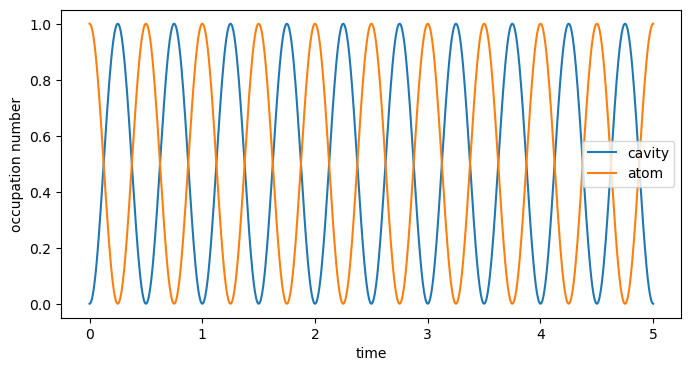

In [21]:
#initial state, cavity in vacuum state, qubit in excited state
#rabi oscillations
psi_1 = tensor(basis(N,0), basis(2,1))
result_1 = mesolve(H_1, psi_1, time, [], [a.dag() * a, sm.dag() *sm])

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(time, result_1.expect[0], label='cavity')
ax.plot(time, result_1.expect[1], label='atom')
ax.set_xlabel('time')
ax.set_ylabel('occupation number')
ax.legend(loc=0)

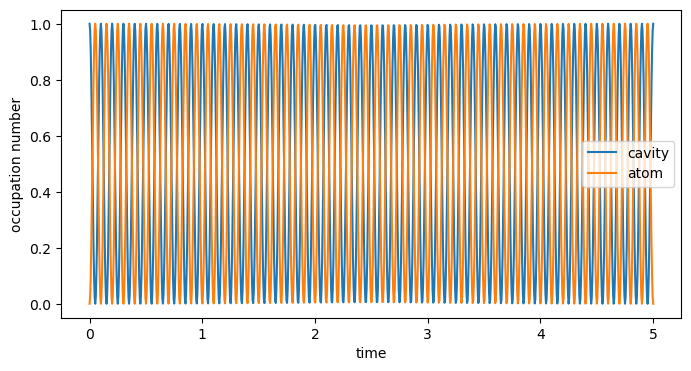

In [26]:
#time evolution for g=5.0
#strong coupling
H_2 = H0 + 5.0 * 2 * np.pi * H1  #g=1.0
psi_2 = tensor(basis(N,1), basis(2,0))  #cavity in first excited state, qubit in ground state

result_2 = mesolve(H_2, psi_2, time, [], [a.dag() * a, sm.dag() *sm])

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(time, result_2.expect[0], label='cavity')
ax.plot(time, result_2.expect[1], label='atom')
ax.set_xlabel('time')
ax.set_ylabel('occupation number')
ax.legend(loc=0)

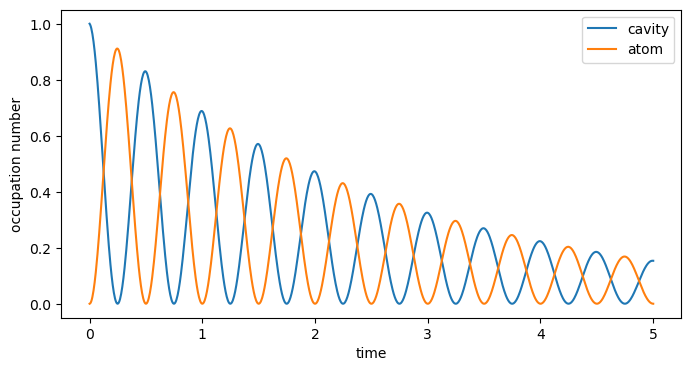

In [28]:
#including dissipation
kappa = 0.25  #cavity dissipation rate
gamma = 0.25  #atom dissipation rate
n_th = 1

c_ops = []
c_ops.append(np.sqrt(kappa * (1 + n_th)) * a)  #cavity dissipation
#c_ops.append(np.sqrt(kappa * n_th) * a.dag())  #cavity excitation
c_ops.append(np.sqrt(gamma) * sm)  #atom dissipation

H_3 = H0 + 1.0 * 2 * np.pi * H1  #g=1.0
psi_3 = tensor(basis(N,1), basis(2,0))

result_3 = mesolve(H_3, psi_3, time, c_ops, [a.dag() * a, sm.dag() *sm])

fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(time, result_3.expect[0], label='cavity')
ax.plot(time, result_3.expect[1], label='atom')
ax.set_xlabel('time')
ax.set_ylabel('occupation number')
ax.legend(loc=0)